# 04 — Classical baselines

Fits and evaluates the three classical baselines from the synopsis — (1)
**persistence**, (2) **day-of-year climatology**, and (3) **dynamic harmonic
regression** (DHR: Fourier annual harmonics with AR(1) errors, a SARIMA-class
model) — per site, at the 1-day and 7-day horizons, under a direct forecasting
strategy (predictors restricted to information available at the forecast
origin *t*).

Split (from `src/config.py`): **train 2005–2020**, **validation 2021–2022**.
Metrics: RMSE, MAE, R². The 2023–2024 **test set stays untouched** until
notebook 06. These baselines are the reference against which the ML models
(notebook 05) must show a ≥ 15% RMSE reduction (RQ1).

In [1]:
import sys, warnings
sys.path.append('../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import (SITES, PARAMETERS, START, END, DATA_RAW, DATA_PROCESSED,
                    RESULTS, TRAIN_END, VAL_END)

TARGET = 'ALLSKY_SFC_SW_DWN'
FIGDIR = RESULTS / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# Sites ordered north -> south; fixed colour per site (Okabe-Ito subset,
# colour-blind-safe; validated for adjacent-pair CVD separation).
SITE_ORDER = ['navrongo', 'tamale', 'kumasi', 'accra', 'takoradi']
SITE_COLOR = {'navrongo': '#D55E00', 'tamale': '#0072B2', 'kumasi': '#009E73',
              'accra': '#E69F00', 'takoradi': '#CC79A7'}
SITE_LABEL = {k: SITES[k]['name'] for k in SITES}

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})


In [2]:
df = pd.read_csv(DATA_PROCESSED / 'all_sites_daily.csv', parse_dates=['date'])
df = df.set_index('date')
HORIZONS = [1, 7]
train_end = pd.Timestamp(TRAIN_END)
val_end = pd.Timestamp(VAL_END)

def metrics(y, yhat):
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    rmse = float(np.sqrt(np.mean((y - yhat) ** 2)))
    mae = float(np.mean(np.abs(y - yhat)))
    r2 = float(1 - np.sum((y - yhat) ** 2) / np.sum((y - y.mean()) ** 2))
    return rmse, mae, r2

## 4.1 Baseline definitions

- **Persistence** — $\hat{y}_{t+h} = y_t$: tomorrow (or day $t{+}7$) equals today.
- **Day-of-year climatology** — $\hat{y}_{t+h} = \bar{y}_{\mathrm{doy}(t+h)}$,
  the 2005–2020 mean GHI for that calendar day (computed from the training
  window only).
- **Dynamic harmonic regression (DHR)** — a regression of GHI on $K{=}3$ annual
  Fourier harmonics with AR(1) errors,
  $y_t = \beta_0 + \sum_{k=1}^{3}\big[a_k \sin(2\pi k\, d_t/365.25) + b_k \cos(2\pi k\, d_t/365.25)\big] + e_t$,
  $e_t = \phi\, e_{t-1} + \varepsilon_t$, estimated on the training window
  (statsmodels SARIMAX). The $h$-step forecast is
  $\hat{y}_{t+h} = X_{t+h}\hat\beta + \hat\phi^{\,h} e_t$, using only
  information available at the origin $t$.

In [3]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fourier_X(index, K=3):
    doy = index.dayofyear.values
    cols = {'const': np.ones(len(index))}
    for k in range(1, K + 1):
        cols[f'sin{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
        cols[f'cos{k}'] = np.cos(2 * np.pi * k * doy / 365.25)
    return pd.DataFrame(cols, index=index)

results_rows = []
dhr_params = {}
preds_store = {}   # (site, horizon) -> DataFrame of predictions on validation

for key in SITE_ORDER:
    y = df.loc[df['site'] == key, TARGET].dropna()
    y_train = y[y.index <= train_end]
    X_full = fourier_X(y.index)

    # --- DHR fit on train only
    mod = SARIMAX(y_train, exog=fourier_X(y_train.index), order=(1, 0, 0), trend='n')
    res = mod.fit(disp=False)
    phi = float(res.params['ar.L1'])
    beta = res.params[X_full.columns]
    mu = pd.Series(X_full.values @ beta.values, index=y.index)   # seasonal mean, all dates
    e = y - mu                                                    # observed deviation from seasonal mean
    dhr_params[key] = {'phi': round(phi, 3),
                       'sigma2': round(float(res.params['sigma2']), 4),
                       'aic': round(float(res.aic), 1)}

    # --- climatology from train only
    clim = y_train.groupby(y_train.index.dayofyear).mean()

    for h in HORIZONS:
        val_mask = (y.index > train_end) & (y.index <= val_end)
        target = y[val_mask]
        origin = target.index - pd.Timedelta(days=h)

        pred = pd.DataFrame(index=target.index)
        pred['actual'] = target
        pred['Persistence'] = y.reindex(origin).values
        pred['Climatology'] = clim.reindex(target.index.dayofyear).values
        pred['DHR'] = mu[val_mask].values + phi ** h * e.reindex(origin).values
        preds_store[(key, h)] = pred

        for model in ['Persistence', 'Climatology', 'DHR']:
            ok = pred[[ 'actual', model]].dropna()
            rmse, mae, r2 = metrics(ok['actual'], ok[model])
            results_rows.append({'Site': SITE_LABEL[key], 'Horizon': f'{h}-day',
                                 'Model': model, 'RMSE': rmse, 'MAE': mae, 'R2': r2,
                                 'N': len(ok)})

print('DHR fitted parameters per site:', dhr_params)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


DHR fitted parameters per site: {'navrongo': {'phi': 0.163, 'sigma2': 0.8684, 'aic': 15778.1}, 'tamale': {'phi': 0.139, 'sigma2': 0.7419, 'aic': 14858.2}, 'kumasi': {'phi': 0.221, 'sigma2': 0.4217, 'aic': 11556.0}, 'accra': {'phi': 0.16, 'sigma2': 0.7184, 'aic': 14669.7}, 'takoradi': {'phi': 0.23, 'sigma2': 1.0206, 'aic': 16721.9}}


## 4.2 Validation results (2021–2022)

In [4]:
results = pd.DataFrame(results_rows).round(3)
results.to_csv(RESULTS / 'baseline_metrics.csv', index=False)
pivot = results.pivot_table(index=['Horizon', 'Model'], columns='Site', values='RMSE').round(3)
print('RMSE (kWh/m²/day):')
pivot

RMSE (kWh/m²/day):


Site                 Accra  Kumasi  Navrongo  Takoradi  Tamale
Horizon Model                                                 
1-day   Climatology  0.883   0.717     0.981     1.033   0.928
        DHR          0.863   0.699     0.939     0.992   0.882
        Persistence  1.133   0.911     1.207     1.257   1.111
7-day   Climatology  0.883   0.717     0.981     1.033   0.928
        DHR          0.874   0.709     0.959     1.023   0.905
        Persistence  1.240   0.980     1.329     1.487   1.257

In [5]:
best = (results.sort_values('RMSE').groupby(['Site', 'Horizon']).first()
        .reset_index()[['Site', 'Horizon', 'Model', 'RMSE', 'MAE', 'R2']])
print('Best classical baseline per site & horizon:')
best

Best classical baseline per site & horizon:


,Site,Horizon,Model,RMSE,MAE,R2
0,Accra,1-day,DHR,0.863,0.625,0.091
1,Accra,7-day,DHR,0.874,0.638,0.067
2,Kumasi,1-day,DHR,0.699,0.509,0.259
3,Kumasi,7-day,DHR,0.709,0.524,0.238
4,Navrongo,1-day,DHR,0.939,0.686,0.189
5,Navrongo,7-day,DHR,0.959,0.720,0.154
6,Takoradi,1-day,DHR,0.992,0.749,0.095
7,Takoradi,7-day,DHR,1.023,0.781,0.037
8,Tamale,1-day,DHR,0.882,0.655,0.218
9,Tamale,7-day,DHR,0.905,0.686,0.178


### Figure 4-1 — RMSE by site, model, and horizon

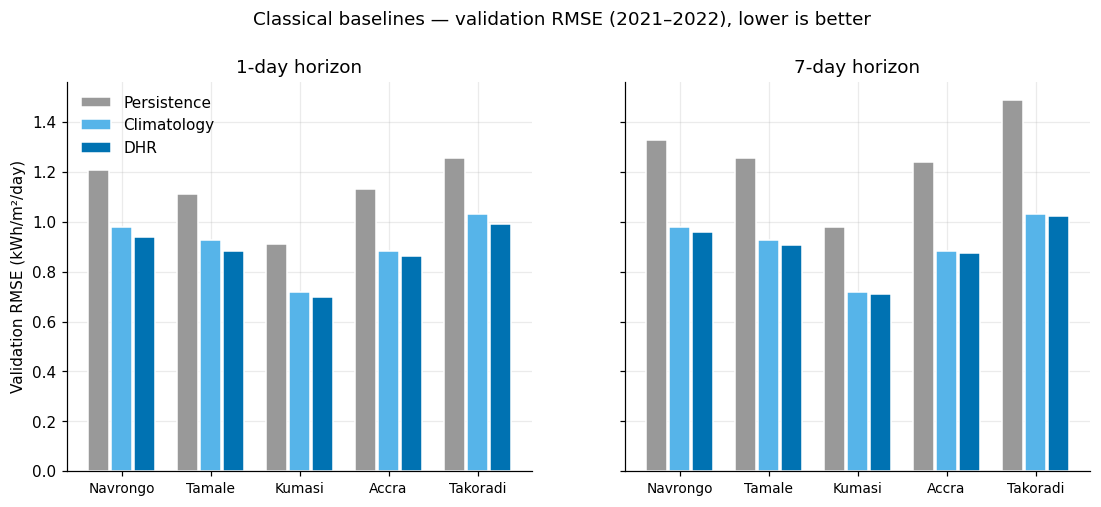

In [6]:
MODEL_COLOR = {'Persistence': '#999999', 'Climatology': '#56B4E9', 'DHR': '#0072B2'}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
width = 0.26
xs = np.arange(len(SITE_ORDER))
for ax, h in zip(axes, HORIZONS):
    sub = results[results['Horizon'] == f'{h}-day']
    for i, model in enumerate(['Persistence', 'Climatology', 'DHR']):
        vals = [sub[(sub['Site'] == SITE_LABEL[k]) & (sub['Model'] == model)]['RMSE'].iloc[0]
                for k in SITE_ORDER]
        ax.bar(xs + (i - 1) * width, vals, width - 0.03, color=MODEL_COLOR[model],
               label=model, edgecolor='white', linewidth=1)
    ax.set_xticks(xs); ax.set_xticklabels([SITE_LABEL[k] for k in SITE_ORDER], fontsize=9)
    ax.set_title(f'{h}-day horizon')
axes[0].set_ylabel('Validation RMSE (kWh/m²/day)')
axes[0].legend(frameon=False)
fig.suptitle('Classical baselines — validation RMSE (2021–2022), lower is better', y=1.02)
fig.savefig(FIGDIR / 'fig_04_1_baseline_rmse.png')
plt.show()

### Figure 4-2 — Example trace (Accra, 1-day horizon, Jan–Jun 2021)

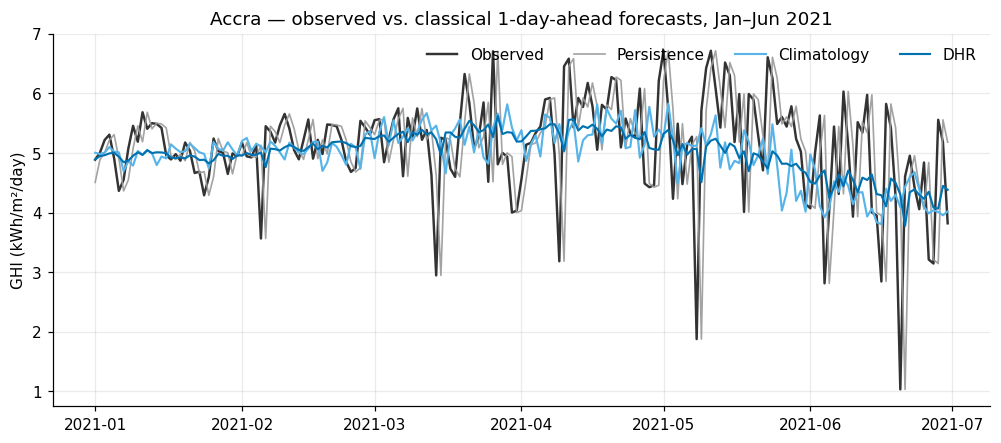

In [7]:
pred = preds_store[('accra', 1)].loc['2021-01-01':'2021-06-30']
fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(pred.index, pred['actual'], color='#333333', lw=1.6, label='Observed')
ax.plot(pred.index, pred['Persistence'], color='#999999', lw=1.1, alpha=0.9, label='Persistence')
ax.plot(pred.index, pred['Climatology'], color='#56B4E9', lw=1.4, label='Climatology')
ax.plot(pred.index, pred['DHR'], color='#0072B2', lw=1.4, label='DHR')
ax.set_ylabel('GHI (kWh/m²/day)')
ax.set_title('Accra — observed vs. classical 1-day-ahead forecasts, Jan–Jun 2021')
ax.legend(frameon=False, ncol=4, loc='upper right')
fig.savefig(FIGDIR / 'fig_04_2_accra_trace.png')
plt.show()

**Interpretation.**

1. **Persistence is the weakest baseline everywhere** — negative R² at both horizons
   at all five sites. Daily GHI is too noisy for "tomorrow = today", and errors grow
   further by day 7 (e.g., Takoradi RMSE 1.26 → 1.49 kWh/m²/day).
2. **DHR is the best classical model at every site and both horizons** (1-day RMSE
   0.70–0.99 kWh/m²/day), beating raw climatology by ≈ 2–5%. The fitted AR(1)
   coefficients are small (φ ≈ 0.14–0.23), so the anomaly term helps mainly at the
   1-day horizon; by 7 days φ⁷ ≈ 0, and DHR collapses onto the seasonal mean — which
   is why its 7-day scores are near-identical to climatology's. Real 7-day skill,
   if any, will have to come from the ML models' richer feature set.
3. **Forecastability tracks climate.** Kumasi is the easiest site (RMSE 0.70, R² 0.26)
   and Takoradi the hardest (RMSE 0.99, R² 0.10) — the coastal wet season identified
   in the EDA is where all classical models lose skill.
4. **Reference targets for RQ1.** The ≥ 15% RMSE-reduction target for the ML models is
   now concrete: at the 1-day horizon they must reach ≈ 0.80 (Navrongo), 0.75
   (Tamale), 0.59 (Kumasi), 0.73 (Accra) and 0.84 (Takoradi) kWh/m²/day against DHR.
   Formal significance testing (Diebold–Mariano) follows on the untouched test set in
   notebook 06.

## 4.3 Next steps

- **Notebook 05** — random forest and XGBoost (tabular features: meteorological
  drivers, GHI lags 1–7, rolling means, day-of-year harmonics) and LSTM (30-day
  windows), tuned with time-series cross-validation on the training window and
  compared on this same validation set at h = 1 and h = 7.
- **Notebook 06** — final evaluation of all models on the untouched 2023–2024 test
  set; Diebold–Mariano tests vs. DHR (RQ1), SHAP feature importance (RQ2), seasonal
  and zonal stratification (RQ3).
- Baseline metrics are saved to `results/baseline_metrics.csv`; figures to
  `results/figures/`.